In [1]:
import numpy as np
import os
import matplotlib.pyplot as plt
from numpy import pi

PATH = os.getcwd()
print(PATH + '/')
print(os.listdir(PATH))

/home/andre/Documents/Git/FOCYou/Simulacao/
['bldc.ipynb', '.ipynb_checkpoints', 'README.md']


In [2]:
def back_emf_trapezoidal(theta):
    """
    Back-EMF trapezoidal normalizada (-1 a +1).
    theta em radianos.
    """

    theta = np.mod(theta, 2*np.pi)

    if theta < np.pi/6:
        return 6*theta/np.pi

    elif theta < 5*np.pi/6:
        return 1.0

    elif theta < 7*np.pi/6:
        return 1 - 6*(theta-5*np.pi/6)/np.pi

    elif theta < 11*np.pi/6:
        return -1.0

    else:
        return -1 + 6*(theta-11*np.pi/6)/np.pi

# Dados do motor

In [3]:
# Resistencia de armadura
Rs = 1 #Ohm

# Indutancia de magnetizacao
L = 5e-3 #H

# Constantes eletricas e mecanicas
Ke = 5e-2
Kt = Ke

# Torque da carga
Tl = 0.1

# Coeficiente de amortecimento
B = 1e-4

# Momento de inercia
J = 1e-3

# Frequencia da rede
# fs = 60 #Hz
# omega_s = 2*pi*fs #rad/s

# Quantidade de Polos no motor
POLOS = 4
PARES_DE_POLOS = POLOS / 2

# Amplitude da rede
Vm = 12 #V

# Defasagens das fases
PHI_A = 0
PHI_B = -2*pi/3
PHI_C = 2*pi/3

# Tensoes de fase
# Va = V*np.sin(we*time + PHI_A)
# Vb = V*np.sin(we*time + PHI_B)
# Vc = V*np.sin(we*time + PHI_C)

# Variáveis de simulação

In [4]:
TEMPO_MAX = 0.5     # s
dt = 1e-5         # s

time = np.arange(0, TEMPO_MAX, dt)
N = len(time)

# Simulação em malha aberta

In [5]:
theta_r = np.zeros(N)
omega_r = np.zeros(N)

ia = np.zeros(N)
ib = np.zeros(N)
ic = np.zeros(N)

Te = np.zeros(N)

Va = np.zeros(N)
Vb = np.zeros(N)
Vc = np.zeros(N)

ea = np.zeros(N)
eb = np.zeros(N)
ec = np.zeros(N)

for k in range(N-1):

    # Ângulo e velocidade elétrica do rotor
    theta_e = PARES_DE_POLOS * theta_r[k]

    # Tensões trifásicas da alimentação
    Va[k] = Vm * np.sin(theta_e  + PHI_A)
    Vb[k] = Vm * np.sin(theta_e  + PHI_B)
    Vc[k] = Vm * np.sin(theta_e  + PHI_C)

    # Back-EMF
    ea[k] = Ke * omega_r[k] * np.sin(theta_e + PHI_A)
    eb[k] = Ke * omega_r[k] * np.sin(theta_e + PHI_B)
    ec[k] = Ke * omega_r[k] * np.sin(theta_e + PHI_C)

    # ea[k] = Ke*omega_r[k]*back_emf_trapezoidal(theta_e + PHI_A)
    # eb[k] = Ke*omega_r[k]*back_emf_trapezoidal(theta_e + PHI_B)
    # ec[k] = Ke*omega_r[k]*back_emf_trapezoidal(theta_e + PHI_C)
    
    # Derivadas das correntes
    dia = (Va[k] - Rs * ia[k] - ea[k]) / L
    dib = (Vb[k] - Rs * ib[k] - eb[k]) / L
    dic = (Vc[k] - Rs * ic[k] - ec[k]) / L

    # Integração (Euler)
    ia[k+1] = ia[k] + dia * dt
    ib[k+1] = ib[k] + dib * dt
    ic[k+1] = ic[k] + dic * dt

    # Torque eletromagnético
    Te[k] = Kt * (
        ia[k] * np.sin(theta_e + PHI_A) +
        ib[k] * np.sin(theta_e + PHI_B) +
        ic[k] * np.sin(theta_e + PHI_C)
    )

    # Dinâmica mecânica
    domega = (Te[k] - Tl - B * omega_r[k]) / J

    omega_r[k+1] = omega_r[k] + domega * dt
    theta_r[k+1] = theta_r[k] + omega_r[k+1] * dt

# Gráficos da simulção de malha aberta

## Tensões

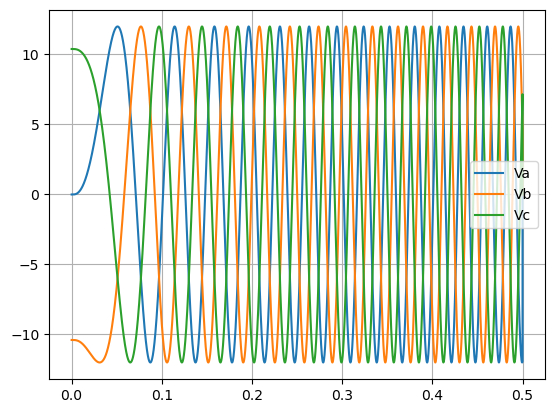

In [6]:
plt.plot(time, Va, label="Va")
plt.plot(time, Vb, label="Vb")
plt.plot(time, Vc, label="Vc")

plt.grid()
plt.legend()

plt.show()

# Correntes

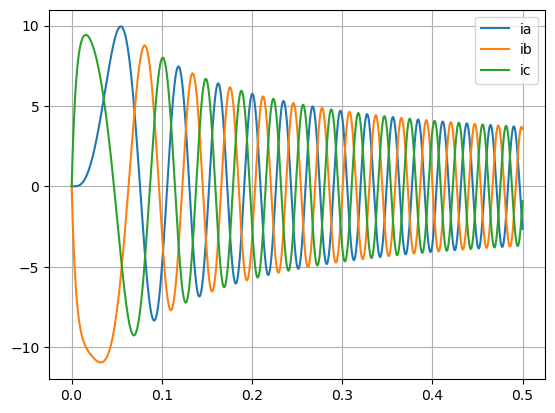

In [7]:
plt.plot(time, ia, label="ia")
plt.plot(time, ib, label="ib")
plt.plot(time, ic, label="ic")

plt.grid()
plt.legend()

plt.show()



## Velocidade

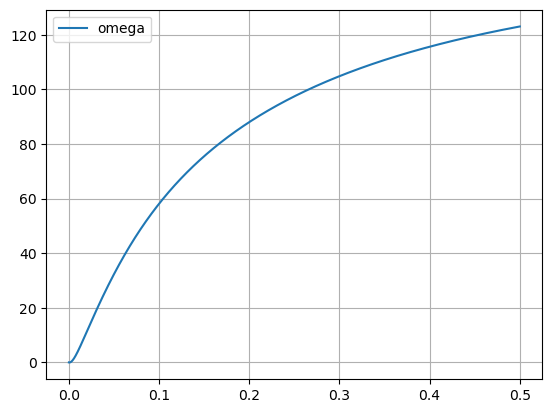

In [8]:
plt.plot(time,omega_r, label='omega')

plt.grid()
plt.legend()

plt.show()

## Torque

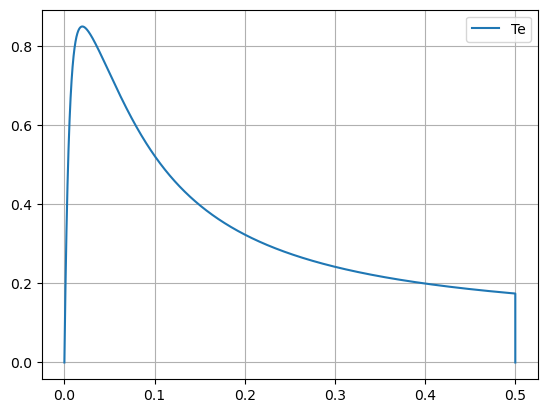

In [9]:
plt.plot(time, Te, label="Te")

plt.grid()
plt.legend()

plt.show()

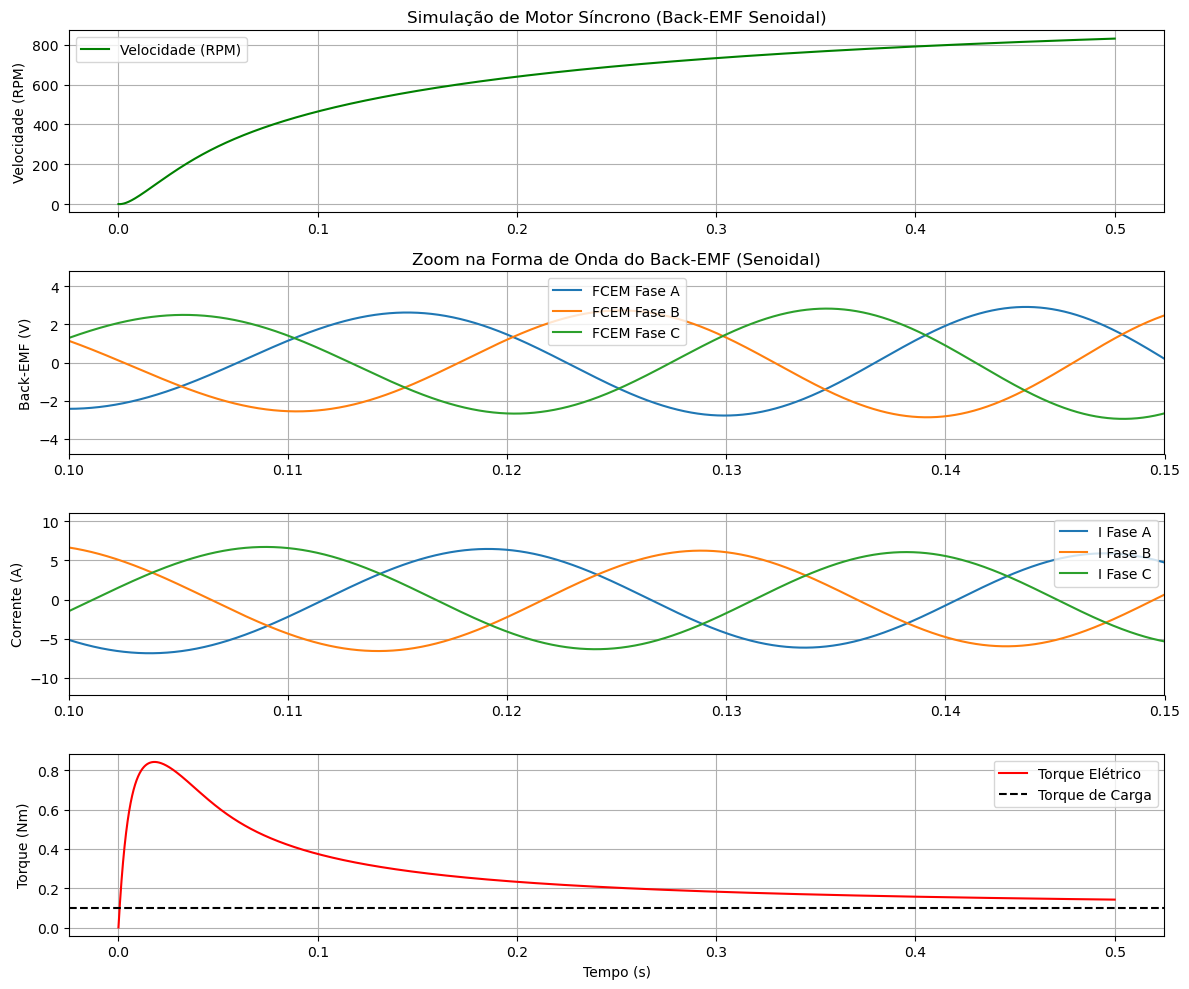

830.7680367921151


In [5]:
import numpy as np
import matplotlib.pyplot as plt

# --------------------------------------------------------------------------
# 1. PARÂMETROS DO MOTOR E DA SIMULAÇÃO
# --------------------------------------------------------------------------
R = 1.0        # Resistência por fase (Ohms)
L = 0.005      # Indutância por fase (Henry)
Ke = 0.05      # Constante de FCEM pico (V/(rad/s))
Kt = 0.05      # Constante de Torque (Nm/A)
J = 0.001      # Inércia do Rotor (kg*m^2)
B = 0.0001     # Coeficiente de atrito viscoso (Nm/(rad/s))
P = 4          # Número de pares de polos

# Configurações de Operação (Alimentação Senoidal Equilibrada)
V_peak = 12.0  # Amplitude de tensão de pico por fase (Volts)
T_load = 0.1   # Torque de carga aplicado (Nm)

# Parâmetros de Tempo
dt = 1e-5      # Passo do tempo da simulação (10 microssegundos)
t_end = 0.5    # Tempo total de simulação (segundos)
steps = int(t_end / dt)

# --------------------------------------------------------------------------
# 2. INICIALIZAÇÃO DE VARIÁVEIS
# --------------------------------------------------------------------------
i_abc = np.zeros(3)  # Correntes nas fases A, B e C
omega = 0.0          # Velocidade angular mecânica (rad/s)
theta = 0.0          # Posição mecânica do rotor (rad)

# Histórico para plotagem
history_t = np.zeros(steps)
history_w = np.zeros(steps)
history_i = np.zeros((steps, 3))
history_e = np.zeros((steps, 3)) # Histórico do Back-EMF
history_tq = np.zeros(steps)

# --------------------------------------------------------------------------
# 3. LOOP PRINCIPAL DA SIMULAÇÃO (Método de Euler)
# --------------------------------------------------------------------------
for step in range(steps):
    t = step * dt
    theta_elec = theta * P  # Posição Elétrica do rotor
    
    # 1. Calcular Força Contra-Eletromotriz (Senoidal puramente defasada em 120°)
    # Em motores reais, o torque máximo ocorre quando a corrente está em fase com o Back-EMF
    e_a = np.sin(theta_elec)
    e_b = np.sin(theta_elec - 2 * np.pi / 3)
    e_c = np.sin(theta_elec + 2 * np.pi / 3)
    e_abc = np.array([e_a, e_b, e_c]) * Ke * omega
    
    # 2. Fontes de Tensão Senoidais Síncronas (Inversor Ideal acompanhando o rotor)
    # Para simplificar e garantir rotação, injetamos tensão alinhada com a posição elétrica
    v_a = np.sin(theta_elec)
    v_b = np.sin(theta_elec - 2 * np.pi / 3)
    v_c = np.sin(theta_elec + 2 * np.pi / 3)
    v_abc = np.array([v_a, v_b, v_c]) * V_peak
    
    # 3. Equações Dinâmicas Elétricas: di/dt = (V - R*i - E) / L
    di_abc = (v_abc - R * i_abc - e_abc) / L
    i_abc += di_abc * dt
    
    # 4. Cálculo do Torque Eletromagnético Total (Soma das potências das 3 fases / omega)
    # Te = Kt * (e_a*i_a + e_b*i_b + e_c*i_c) / (Ke * omega) -> Simplifica para o produto escalar abaixo:
    # Nota: Usamos a forma normalizada do vetor senoidal para extrair o torque correto
    e_normalized = np.array([e_a, e_b, e_c])
    T_e = Kt * np.dot(e_normalized, i_abc)
    
    # 5. Equações Dinâmicas Mecânicas: dw/dt = (T_e - T_load - B*w) / J
    d_omega = (T_e - T_load - B * omega) / J
    omega += d_omega * dt
    
    # 6. Atualizar Posição: dtheta/dt = omega
    theta += omega * dt
    
    # Salvar dados no histórico
    history_t[step] = t
    history_w[step] = omega * (30 / np.pi)  # Converte rad/s para RPM
    history_i[step] = i_abc
    history_e[step] = e_abc
    history_tq[step] = T_e

# --------------------------------------------------------------------------
# 4. VISUALIZAÇÃO DOS RESULTADOS
# --------------------------------------------------------------------------
plt.figure(figsize=(12, 10))

# Gráfico de Velocidade
plt.subplot(4, 1, 1)
plt.plot(history_t, history_w, 'g-', label='Velocidade (RPM)')
plt.title('Simulação de Motor Síncrono (Back-EMF Senoidal)')
plt.ylabel('Velocidade (RPM)')
plt.grid(True)
plt.legend()

# Gráfico do Back-EMF (Foco no início para ver a forma de onda)
plt.subplot(4, 1, 2)
plt.plot(history_t, history_e[:, 0], label='FCEM Fase A')
plt.plot(history_t, history_e[:, 1], label='FCEM Fase B')
plt.plot(history_t, history_e[:, 2], label='FCEM Fase C')
plt.ylabel('Back-EMF (V)')
plt.xlim([0.1, 0.15]) # Janela de zoom fixada para ver as senoides
plt.title('Zoom na Forma de Onda do Back-EMF (Senoidal)')
plt.grid(True)
plt.legend()

# Gráfico de Correntes de Fase
plt.subplot(4, 1, 3)
plt.plot(history_t, history_i[:, 0], label='I Fase A')
plt.plot(history_t, history_i[:, 1], label='I Fase B')
plt.plot(history_t, history_i[:, 2], label='I Fase C')
plt.ylabel('Corrente (A)')
plt.xlim([0.1, 0.15]) # Mesmo zoom para ver o alinhamento
plt.grid(True)
plt.legend()

# Gráfico de Torque Eletromagnético
plt.subplot(4, 1, 4)
plt.plot(history_t, history_tq, 'r-', label='Torque Elétrico')
plt.axhline(y=T_load, color='k', linestyle='--', label='Torque de Carga')
plt.xlabel('Tempo (s)')
plt.ylabel('Torque (Nm)')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

print(np.max(history_w))
